In [1]:
import json
import os
import re
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

from students.kudryavcev.lesson3 import Exercise, LinearLayer, Model

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

print(f"Размер датасета: {X.shape}")
print(f"Классов: {len(np.unique(y))}")
# 60/20/20
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Тренировочная выборка: {len(X_train)} объектов")
print(f"Валидационная выборка: {len(X_val)} объектов")
print(f"Тестовая выборка: {len(X_test)} объектов")

Размер датасета: (1797, 64)
Классов: 10
Тренировочная выборка: 1077 объектов
Валидационная выборка: 360 объектов
Тестовая выборка: 360 объектов


In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

X_trainval_norm = np.vstack([X_train_norm, X_val_norm])
y_trainval = np.concatenate([y_train, y_val])

In [4]:
def save_model(model: Model, filepath: str, arch_name: str, config: list[tuple[int, str]]):
    params = dict()
    idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            params[f"weight_{idx}"] = layer.weights
            params[f"bias_{idx}"] = layer.bias
            idx += 1

    params["arch_name"] = np.array(arch_name)
    params["config"] = np.array(json.dumps(config))

    np.savez(filepath, **params)
    print(f"Модель сохранена в {filepath}")


def load_model(model: Model, filepath: str):
    if not os.path.exists(filepath):
        return
    data = np.load(filepath)
    idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            layer.weights = data[f"weight_{idx}"]
            layer.bias = data[f"bias_{idx}"]
            idx += 1
    print(f"Модель успешно загружена из {filepath}")


def build_model(
    in_features: int, out_features: int, hidden_layers: list[tuple[int, str]], rng: np.random.Generator
) -> Model:
    layers = []
    current_features = in_features

    for hidden_size, activation in hidden_layers:
        layers.append(Exercise.create_linear_layer(current_features, hidden_size, rng))
        if activation == "relu":
            layers.append(Exercise.create_relu_layer())
        elif activation == "sigmoid":
            layers.append(Exercise.create_sigmoid_layer())
        current_features = hidden_size

    layers.append(Exercise.create_linear_layer(current_features, out_features, rng))
    return Exercise.create_model(*layers)

In [5]:
def evaluate_config(lr, batch_size, n_epoch, hidden_layers, seed):
    rng = np.random.default_rng(seed)
    in_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    model = build_model(in_features, n_classes, hidden_layers, rng)
    loss_fn = Exercise.create_cross_entropy_loss()

    Exercise.train_model(
        model=model,
        loss=loss_fn,
        x=X_train_norm,
        y=y_train,
        lr=lr,
        n_epoch=n_epoch,
        batch_size=batch_size if batch_size is not None else len(X_train_norm),
        shuffle=True,
    )

    val_predictions = model.forward(X_val_norm)
    val_pred_classes = np.argmax(val_predictions, axis=1)

    return float(np.mean(val_pred_classes == y_val))

In [6]:
def sanitize_filename(text: str) -> str:
    text = text.replace(" ", "_").replace(",", "")
    text = re.sub(r"[^A-Za-zА-Яа-я0-9_.\-]", "_", text)
    return text


def make_model_filename(arch_name: str, lr: float, batch_size, n_epoch: int, acc: float) -> str:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    arch_tag = sanitize_filename(arch_name)
    lr_tag = f"lr{lr}"
    bs_tag = f"bs{batch_size}"
    ep_tag = f"ep{n_epoch}"
    acc_tag = f"acc{acc:.4f}"
    return f"{timestamp}_{arch_tag}_{lr_tag}_{bs_tag}_{ep_tag}_{acc_tag}.npz"

In [7]:
learning_rates = [0.5]
batch_sizes = [256]
epochs_list = [750]
hidden_architectures = [
    ([(16, "relu")], "1 слой по 16 (relu)"),
]
"""hidden_architectures = [
    ([(16, "relu")], "1 слой по 16 (relu)"),
    ([(32, "relu")], "1 слой по 32 (relu)"),
    ([(64, "relu")], "1 слой по 64 (relu)"),
    ([(32, "sigmoid")], "1 слой по 32 (sigmoid)"),
    ([(64, "relu"), (32, "relu")], "2 слоя (64, 32) оба relu"),
    ([(64, "relu"), (32, "sigmoid")], "2 слоя (64 relu, 32 sigmoid)"),
    ([(64, "relu"), (32, "sigmoid"), (16, "relu")], "3 слоя (64 relu, 32 sigmoid, 16 relu)"),
]"""
seeds = [42, 100, 999]

results = []

print("Тестирование идёт...")
for lr in learning_rates:
    for bs in batch_sizes:
        for n_epoch in epochs_list:
            for config, arch_name in hidden_architectures:
                acc_scores = []
                for seed in seeds:
                    acc = evaluate_config(lr, bs, n_epoch, config, seed)
                    acc_scores.append(acc)

                results.append(
                    {
                        "architecture": arch_name,
                        "config": config,
                        "lr": lr,
                        "batch_size": bs if bs is not None else "Full batch",
                        "n_epoch": n_epoch,
                        "mean_accuracy": np.mean(acc_scores),
                        "std_accuracy": np.std(acc_scores),
                    }
                )

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["mean_accuracy"], ascending=False).reset_index(drop=True)
display(df_results.drop(columns=["config"]).head(5))

best_result = df_results.iloc[0]
best_arch = best_result["architecture"]
best_config = best_result["config"]
best_lr = best_result["lr"]
best_bs = best_result["batch_size"]
best_epoch = best_result["n_epoch"]

print("\n--- Выбрана Лучшая Модель ---")
print("Параметры:", dict(best_result))

rng_final = np.random.default_rng(2026)
final_model = build_model(X_train.shape[1], len(np.unique(y_train)), best_config, rng_final)
loss_fn = Exercise.create_cross_entropy_loss()

Exercise.train_model(
    model=final_model,
    loss=loss_fn,
    x=X_trainval_norm,
    y=y_trainval,
    lr=best_lr,
    n_epoch=best_epoch,
    batch_size=len(X_trainval_norm) if best_bs == "Full batch" else best_bs,
    shuffle=True,
)

test_predictions = final_model.forward(X_test_norm)
test_pred_classes = np.argmax(test_predictions, axis=1)

accuracy = accuracy_score(y_test, test_pred_classes)
print(f"\nФинальная Accuracy на тестовых данных: {accuracy:.4f}")


model_dir = "students/kudryavcev/lesson3"
model_filename = make_model_filename(best_arch, best_lr, best_bs, best_epoch, accuracy)
model_path = os.path.join(model_dir, model_filename)

save_model(final_model, model_path, best_arch, best_config)

Тестирование идёт...


,architecture,lr,batch_size,n_epoch,mean_accuracy,std_accuracy
0,1 слой по 16 (relu),0.5,256,750,0.968519,0.003464



--- Выбрана Лучшая Модель ---
Параметры: {'architecture': '1 слой по 16 (relu)', 'config': [(16, 'relu')], 'lr': np.float64(0.5), 'batch_size': np.int64(256), 'n_epoch': np.int64(750), 'mean_accuracy': np.float64(0.9685185185185184), 'std_accuracy': np.float64(0.00346449758034623)}

Финальная Accuracy на тестовых данных: 0.9722
Модель сохранена в students/kudryavcev/lesson3/20260405_014104_1_слой_по_16__relu__lr0.5_bs256_ep750_acc0.9722.npz


In [29]:
import optuna
from optuna.exceptions import TrialPruned

SEARCH_SEED = 42
MAX_EPOCHS = 5000
PATIENCE = 40
N_TRIALS = 200
STUDY_NAME = "lesson3.1_mlp_search"
STORAGE = "sqlite:///lesson3.1_mlp_search.db"

RECHECK_TOP_K = 10
RECHECK_SEEDS = [123, 111, 42, 999, 777]

optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = optuna.samplers.TPESampler(seed=SEARCH_SEED)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,   # первые trial не prune'им слишком рано
    n_warmup_steps=10,    # первые эпохи внутри trial не prune'им
    interval_steps=1,
)

# =========================
# Вспомогательные функции
# =========================
def accuracy_np(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def evaluate_accuracy(model, x, y):
    logits = model.forward(x)
    pred = np.argmax(logits, axis=1)
    return accuracy_np(y, pred)

def snapshot_params(model):
    return [p.copy() for p in model.parameters]

def restore_params(model, params_snapshot):
    for p, saved in zip(model.parameters, params_snapshot, strict=True):
        p[...] = saved

def train_one_epoch(model, loss_fn, x, y, lr, batch_size, rng):
    n = x.shape[0]
    indices = rng.permutation(n)

    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        xb = x[batch_idx]
        yb = y[batch_idx]

        pred = model.forward(xb)
        loss_value = loss_fn.forward(pred, yb)

        # Защита от NaN/Inf
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"Non-finite loss: {loss_value}")

        dloss = loss_fn.backward()
        model.backward(dloss)

        for param, grad in zip(model.parameters, model.grad, strict=True):
            if not np.all(np.isfinite(grad)):
                raise FloatingPointError("Non-finite gradient encountered")
            param -= lr * grad

            if not np.all(np.isfinite(param)):
                raise FloatingPointError("Non-finite parameter encountered")

def fit_and_validate(
    *,
    lr,
    batch_size,
    hidden_layers,
    seed,
    x_train,
    y_train,
    x_val,
    y_val,
    trial=None,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
):
    """
    Обучает одну конфигурацию.
    Возвращает лучший val_acc за всё обучение.
    Если передан trial, включает pruning.
    """
    rng = np.random.default_rng(seed)

    model = build_model(
        in_features=x_train.shape[1],
        out_features=len(np.unique(y_train)),
        hidden_layers=hidden_layers,
        rng=rng,
    )
    loss_fn = Exercise.create_cross_entropy_loss()

    best_val_acc = -np.inf
    best_state = snapshot_params(model)
    epochs_without_improve = 0

    for epoch in range(max_epochs):
        train_one_epoch(
            model=model,
            loss_fn=loss_fn,
            x=x_train,
            y=y_train,
            lr=lr,
            batch_size=batch_size,
            rng=rng,
        )

        val_acc = evaluate_accuracy(model, x_val, y_val)

        if not np.isfinite(val_acc):
            raise FloatingPointError(f"Non-finite val_acc: {val_acc}")

        # Сообщаем Optuna промежуточный результат
        if trial is not None:
            trial.report(val_acc, step=epoch)
            if trial.should_prune():
                raise TrialPruned() from None

        # Early stopping по лучшей валидации
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = snapshot_params(model)
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            break

    # Возвращаем лучшую эпоху
    restore_params(model, best_state)
    return best_val_acc

def build_hidden_layers_from_trial(trial):
    n_layers = trial.suggest_int("n_layers", 1, 2)

    hidden_layers = []
    for i in range(n_layers):
        units = trial.suggest_categorical(f"units_{i}", [10, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096])
        activation = trial.suggest_categorical(f"activation_{i}", ["relu", "sigmoid"])
        hidden_layers.append((units, activation))

    return hidden_layers


def hidden_layers_from_params(params):
    n_layers = params["n_layers"]
    hidden_layers = []

    for i in range(n_layers):
        units = params[f"units_{i}"]
        activation = params[f"activation_{i}"]
        hidden_layers.append((units, activation))

    return hidden_layers

# =========================
# Objective для Optuna
# =========================
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64, 128, 256, 512, 1024])
    hidden_layers = build_hidden_layers_from_trial(trial)

    try:
        val_acc = fit_and_validate(
            lr=lr,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            seed=SEARCH_SEED,
            x_train=X_train_norm,
            y_train=y_train,
            x_val=X_val_norm,
            y_val=y_val,
            trial=trial,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
        )
    except (FloatingPointError, OverflowError, ValueError) as err:
        # Плохую конфигурацию не валим целиком, а помечаем как pruned
        raise TrialPruned() from err

    return val_acc

# =========================
# Создание / загрузка study
# =========================
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    load_if_exists=True,
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
)

print("\n=== Лучший trial по одной фиксированной инициализации ===")
print("best_params =", study.best_params)
print(f"best_val_acc = {study.best_value:.4f}")

# =========================
# Перепроверка лучших конфигов на нескольких seed
# =========================
complete_trials = [
    t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]
complete_trials = sorted(complete_trials, key=lambda t: t.value, reverse=True)

top_trials = complete_trials[:RECHECK_TOP_K]
if not top_trials:
    raise RuntimeError("Нет завершённых trial для перепроверки.")

def recheck_trial_params(params, seeds):
    lr = params["lr"]
    batch_size = params["batch_size"]
    hidden_layers = hidden_layers_from_params(params)

    scores = []
    for seed in seeds:
        score = fit_and_validate(
            lr=lr,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            seed=seed,
            x_train=X_train_norm,
            y_train=y_train,
            x_val=X_val_norm,
            y_val=y_val,
            trial=None,              # без pruning на recheck
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
        )
        scores.append(score)

    return {
        "mean_val_acc": float(np.mean(scores)),
        "std_val_acc": float(np.std(scores)),
        "scores": scores,
    }

robust_results = []

print("\n=== Перепроверка top trial на нескольких seed ===")
for rank, t in enumerate(top_trials, start=1):
    trial_value = t.value
    if trial_value is None:
        continue

    stats = recheck_trial_params(t.params, RECHECK_SEEDS)
    robust_results.append({
        "trial_number": t.number,
        "original_val_acc": float(trial_value),
        "mean_val_acc": stats["mean_val_acc"],
        "std_val_acc": stats["std_val_acc"],
        "scores": stats["scores"],
        "params": t.params,
    })

    print(
        f"rank={rank} | trial={t.number} | "
        f"single_seed={trial_value:.4f} | "
        f"mean={stats['mean_val_acc']:.4f} | "
        f"std={stats['std_val_acc']:.4f} | "
        f"scores={[round(s, 4) for s in stats['scores']]}"
    )

if not robust_results:
    raise RuntimeError("Нет завершённых trial с числовым значением для перепроверки.")

# Берём уже устойчивого победителя:
# сначала по максимальному mean_val_acc, при равенстве — по меньшему std
robust_results.sort(key=lambda x: (-x["mean_val_acc"], x["std_val_acc"]))
best_robust = robust_results[0]

print("\n=== Лучший устойчивый конфиг после перепроверки ===")
print("trial_number:", best_robust["trial_number"])
print("original_val_acc:", round(best_robust["original_val_acc"], 4))
print("mean_val_acc:", round(best_robust["mean_val_acc"], 4))
print("std_val_acc:", round(best_robust["std_val_acc"], 4))
print("scores:", [round(s, 4) for s in best_robust["scores"]])
print("params:", best_robust["params"])

# Удобные переменные для дальнейшего финального обучения
best_params_robust = best_robust["params"]
best_lr = best_params_robust["lr"]
best_batch_size = best_params_robust["batch_size"]
best_hidden_layers = hidden_layers_from_params(best_params_robust)

print("\n=== Для финального обучения ===")
print("best_lr =", best_lr)
print("best_batch_size =", best_batch_size)
print("best_hidden_layers =", best_hidden_layers)

[I 2026-04-05 04:40:08,219] A new study created in RDB with name: lesson3.1_mlp_search


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-05 04:41:15,912] Trial 0 finished with value: 0.9416666666666667 and parameters: {'lr': 0.0013292918943162175, 'batch_size': 8, 'n_layers': 2, 'units_0': 16, 'activation_0': 'relu', 'units_1': 64, 'activation_1': 'sigmoid'}. Best is trial 0 with value: 0.9416666666666667.
[W 2026-04-05 04:42:49,822] Trial 1 failed with parameters: {'lr': 0.07886714129990492, 'batch_size': 8, 'n_layers': 2, 'units_0': 512, 'activation_0': 'sigmoid', 'units_1': 512, 'activation_1': 'sigmoid'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/vscode/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2860/3821809394.py", line 170, in objective
    val_acc = fit_and_validate(
              ^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2860/3821809394.py", line 102, in fit_and_validate
    train_one_epoch(
  File "/tmp/ipykern

KeyboardInterrupt: 

Архитектура: optuna_2L_512r_32r
Слои: [(512, 'relu'), (32, 'relu')]
lr=0.0536, batch_size=16, epochs=3000

Финальная Accuracy (Optuna) на тесте: 0.9778


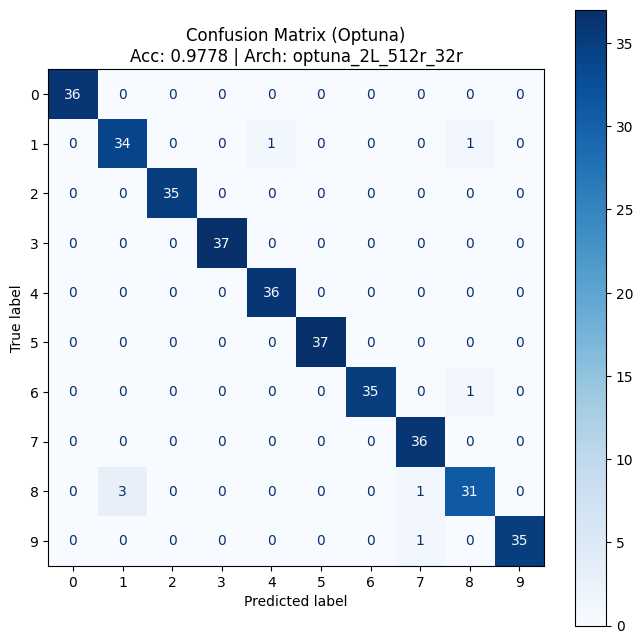

Модель сохранена в students/kudryavcev/lesson3/models/20260405_042640_optuna_2L_512r_32r_lr0.053598641676793374_bs16_ep3000_acc0.9778.npz


In [ ]:
opt_lr = best_lr
opt_bs = best_batch_size
opt_epoch = MAX_EPOCHS
opt_hidden = best_hidden_layers
opt_n_layers = len(opt_hidden)
opt_arch_name = f"optuna_{opt_n_layers}L_" + "_".join(f"{u}{a[0]}" for u, a in opt_hidden)

print(f"Архитектура: {opt_arch_name}")
print(f"Слои: {opt_hidden}")
print(f"lr={opt_lr:.4f}, batch_size={opt_bs}, epochs={opt_epoch}")

rng_optuna = np.random.default_rng(2026)
optuna_model = build_model(X_train.shape[1], len(np.unique(y_train)), opt_hidden, rng_optuna)
optuna_loss = Exercise.create_cross_entropy_loss()

Exercise.train_model(
    model=optuna_model,
    loss=optuna_loss,
    x=X_trainval_norm,
    y=y_trainval,
    lr=opt_lr,
    n_epoch=opt_epoch,
    batch_size=opt_bs,
    shuffle=True,
)

opt_test_pred = optuna_model.forward(X_test_norm)
opt_test_classes = np.argmax(opt_test_pred, axis=1)
opt_accuracy = accuracy_score(y_test, opt_test_classes)
print(f"\nФинальная Accuracy (Optuna) на тесте: {opt_accuracy:.4f}")

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, opt_test_classes, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix (Optuna)\nAcc: {opt_accuracy:.4f} | Arch: {opt_arch_name}")
plt.show()

opt_model_dir = "students/kudryavcev/lesson3/models"
opt_model_filename = make_model_filename(opt_arch_name, opt_lr, opt_bs, opt_epoch, opt_accuracy)
opt_model_path = os.path.join(opt_model_dir, opt_model_filename)
save_model(optuna_model, opt_model_path, opt_arch_name, opt_hidden)

Модель успешно загружена из students/kudryavcev/lesson3/models/20260404_140546_optuna_2L_64r_32r_lr0.030985061815175737_bs64_ep900_acc0.9694.npz

Accuracy: 0.9694
Архитектура: optuna_2L_64r_32r
Конфигурация: [(64, 'relu'), (32, 'relu')]


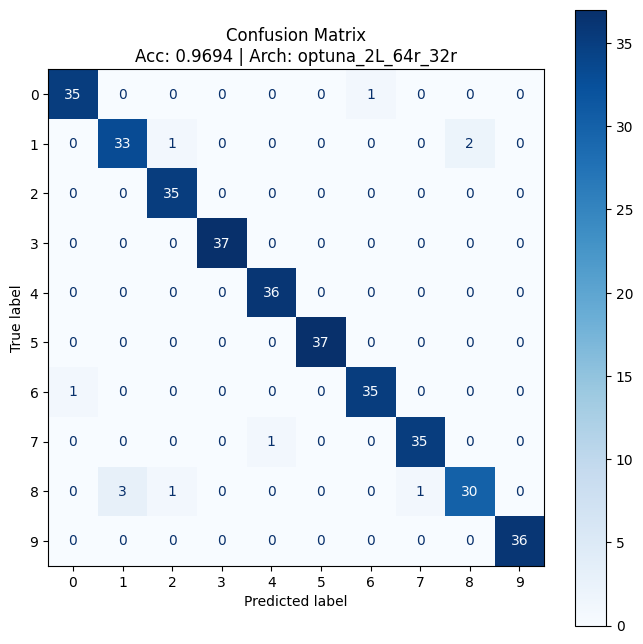

In [ ]:
custom_model_path = (
    "students/kudryavcev/lesson3/models/20260404_140546_optuna_2L_64r_32r_lr0.030985061815175737_bs64_ep900_acc0.9694.npz"
)

data = np.load(custom_model_path, allow_pickle=True)
saved_arch_name = str(data["arch_name"])
saved_config_raw = json.loads(str(data["config"]))
saved_config = [(int(size), str(activation)) for size, activation in saved_config_raw]

loaded_model = build_model(X_train.shape[1], len(np.unique(y_train)), saved_config, np.random.default_rng(999))
load_model(loaded_model, custom_model_path)

load_predictions = loaded_model.forward(X_test_norm)
test_pred_classes = np.argmax(load_predictions, axis=1)

load_acc = accuracy_score(y_test, test_pred_classes)
print(f"\nAccuracy: {load_acc:.4f}")
print(f"Архитектура: {saved_arch_name}")
print(f"Конфигурация: {saved_config}")

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_classes, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix\nAcc: {load_acc:.4f} | Arch: {saved_arch_name}")
plt.show()